In [1]:
import pandas as pd
import src._1_data_prep as dp
import src._2_power_flow_optimization as pfo
import src.config as cfg

In [2]:
df=dp.sort_ship_columns(dp.load_and_prepare_data(),6,0,69)
df.head()

,private_MWh,price_EUR_MWh,business_MWh,CO2_g_MWh,t2m_C,radiation_solaire_factor,AIDANOVA,MSC EURIBIA,IONA,NORWEGIAN PRIMA,...,EUROPA,SEABOURN VENTURE,STAR PRIDE,DEUTSCHLAND,HAMBURG,CORINTHIAN,WORLD VOYAGER,HANSEATIC SPIRIT,HEBRIDEAN SKY,NOORDERLICHT
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0.202830,26.80,0.945704,4730.0,0.75967,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 01:00:00,0.197758,32.80,0.924756,4600.0,0.66458,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 02:00:00,0.192327,31.14,0.927263,3920.0,0.58303,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 03:00:00,0.187711,32.80,0.928286,3790.0,0.46475,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 04:00:00,0.186129,33.10,0.963000,4050.0,0.43105,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
n = pfo.create_pypsa_network_opti(df,PV_nominal_capacity=cfg.SOLAR_CAPACITY_MW, Battery=True, index_ship=6)
n

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 4
 - Carrier: 6
 - Generator: 2
 - Link: 5
 - Load: 71
 - StorageUnit: 1
Snapshots: 8784

In [4]:
# Lancement de l'optimisation (tu peux changer le solver pour 'highs', 'gurobi' ou 'glpk' selon ce que tu as installé)
status, condition = n.optimize()

print(f"Statut de l'optimisation : {status}, {condition}")

# 2. Résultats du dimensionnement (Capacité installée)
print("\n--- DIMENSIONNEMENT OPTIMAL ---")
capacite_solaire_opt = n.generators.loc["solar", "p_nom_opt"]
print(f"Capacité PV optimale installée : {capacite_solaire_opt:.2f} MW")

if "battery" in n.storage_units.index:
    capacite_batterie_opt = n.storage_units.loc["battery", "p_nom_opt"]
    print(f"Capacité Batterie optimale installée : {capacite_batterie_opt:.2f} MW")

/var/folders/_p/lntvskx96x323cvnklm36kvh0000gn/T/ipykernel_1103/3884738538.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = n.optimize()
Index(['bus_main', 'bus_ship', 'bus_solar', 'bus_battery'], dtype='str', name='name')
Index(['link_shore_power', 'link_solar_main', 'link_battery_to_main',
       'link_main_to_battery', 'link_solar_to_battery'],
      dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 888.76it/s]
INFO:linopy.io: Writing time: 0.08s


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-6wqlmhx7 has 219602 rows; 87842 cols; 364916 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 1e+00]
  Cost    [1e-02, 5e+04]
  Bound   [0e+00, 0e+00]
  RHS     [1e-02, 1e+06]
Presolving model
62246 rows, 67019 cols, 182724 nonzeros  0s
53462 rows, 49451 cols, 147588 nonzeros  0s
Dependent equations search running on 22339 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
53462 rows, 49451 cols, 147588 nonzeros  0s
Presolve reductions: rows 53462(-166140); columns 49451(-38391); nonzeros 147588(-217328) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -7.2259979894e+02 Pr: 13556(9.54198e+09) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87842 primals, 219602 duals
Objective: 3.68e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      38713     3.6846900342e+06 Pr: 0(0); Du: 0(5.62087e-13) 1.3s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-6wqlmhx7
Model status        : Optimal
Simplex   iterations: 38713
Objective value     :  3.6846900342e+06
P-D objective error :  6.6348089092e-15
HiGHS run time      :          1.33
Statut de l'optimisation : ok, optimal

--- DIMENSIONNEMENT OPTIMAL ---
Capacité PV optimale installée : 19.30 MW
Capacité Batterie optimale installée : 0.23 MW


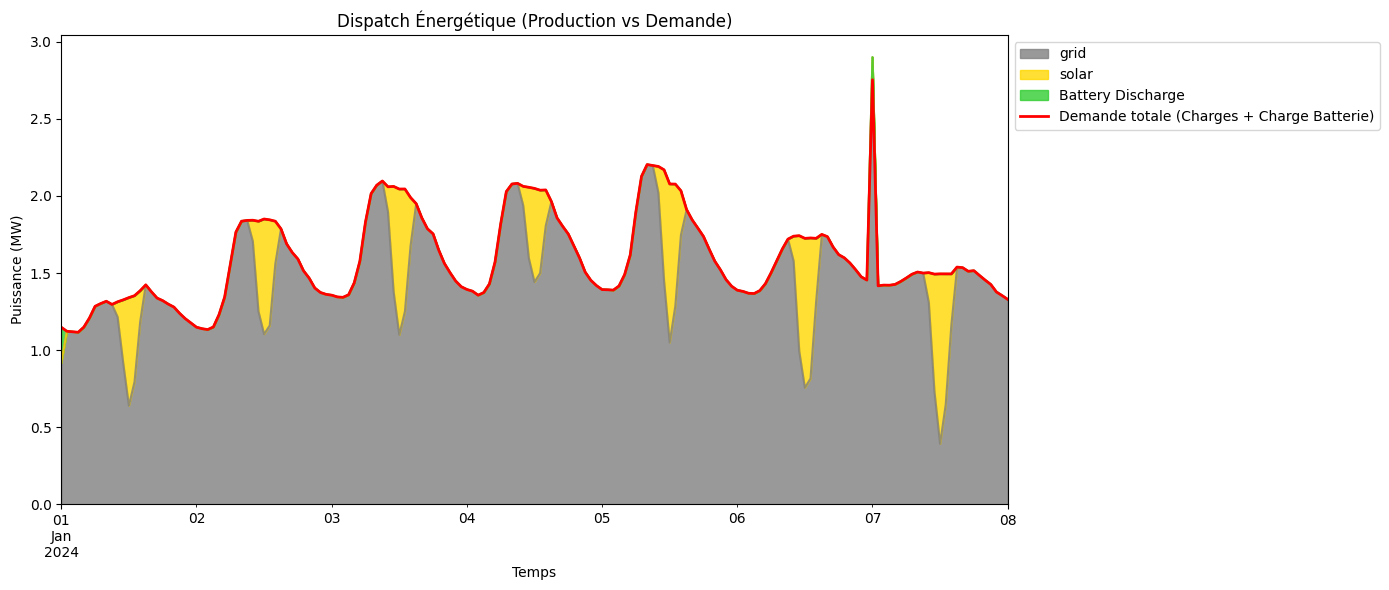

In [5]:
import matplotlib.pyplot as plt
# Choix d'une fenêtre temporelle pour la lisibilité (ex: la première semaine)
start_date = n.snapshots[0]
end_date = n.snapshots[168] # 168 heures = 1 semaine
time_window = slice(start_date, end_date)

# Extraction de la production (Générateurs)
generation = n.generators_t.p.loc[time_window]

# Extraction de la dynamique de la batterie (si elle existe)
if "battery" in n.storage_units.index:
    # Puissance positive = décharge (fournit au réseau), négative = charge
    battery_dispatch = n.storage_units_t.p.loc[time_window, "battery"]
    generation["Battery Discharge"] = battery_dispatch.clip(lower=0)
    charge_battery = battery_dispatch.clip(upper=0).abs()
else:
    charge_battery = pd.Series(0, index=generation.index)

# Calcul de la charge totale (Consommation)
# On somme toutes les charges (business, private, ships)
total_load = n.loads_t.p.loc[time_window].sum(axis=1)
# On ajoute l'énergie utilisée pour charger la batterie
total_demand = total_load + charge_battery

# Création du graphique
fig, ax = plt.subplots(figsize=(14, 6))

# Couleurs pour la clarté
colors = {"grid": "gray", "solar": "gold", "Battery Discharge": "limegreen"}

generation.plot(kind="area", stacked=True, ax=ax, color=[colors.get(c, "blue") for c in generation.columns], alpha=0.8)

# Ligne de la demande totale
total_demand.plot(ax=ax, color='red', linewidth=2, label='Demande totale (Charges + Charge Batterie)')

ax.set_title("Dispatch Énergétique (Production vs Demande)")
ax.set_ylabel("Puissance (MW)")
ax.set_xlabel("Temps")
ax.legend(loc="best", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [6]:
import plotly.graph_objects as go
import pandas as pd

# 1. Extraction sur TOUTE la période (plus de slice initial)
generation = n.generators_t.p.copy()

# Extraction de la dynamique de la batterie (si elle existe)
if "battery" in n.storage_units.index:
    # Puissance positive = décharge (fournit au réseau), négative = charge
    battery_dispatch = n.storage_units_t.p["battery"]
    generation["Battery Discharge"] = battery_dispatch.clip(lower=0)
    charge_battery = battery_dispatch.clip(upper=0).abs()
else:
    charge_battery = pd.Series(0, index=generation.index)

# Calcul de la charge totale (Consommation)
total_load = n.loads_t.p.sum(axis=1)
total_demand = total_load + charge_battery

# 2. Création du graphique Plotly
fig = go.Figure()

# Couleurs pour la clarté
colors = {"grid": "gray", "solar": "gold", "Battery Discharge": "limegreen"}

# Ajout des aires empilées pour la production
for col in generation.columns:
    color = colors.get(col, "blue") # Bleu par défaut si non spécifié
    fig.add_trace(go.Scatter(
        x=generation.index,
        y=generation[col],
        mode='lines',
        line=dict(width=0, color=color),
        fillcolor=color,
        stackgroup='one', # L'argument magique pour empiler les aires (stacked area)
        name=col
    ))

# Ajout de la ligne de la demande totale par-dessus
fig.add_trace(go.Scatter(
    x=total_demand.index,
    y=total_demand,
    mode='lines',
    line=dict(color='red', width=2),
    name='Demande totale (Charges + Charge Batt.)'
))

# 3. Mise en forme et ajout de l'interactivité (Slider semaine par semaine)
fig.update_layout(
    title="Dispatch Énergétique (Production vs Demande)",
    xaxis_title="Temps",
    yaxis_title="Puissance (MW)",
    hovermode="x unified", # Affiche un résumé de toutes les courbes au survol
    template="plotly_white",
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=7, label="1 Semaine", step="day", stepmode="backward"),
                dict(count=1, label="1 Mois", step="month", stepmode="backward"),
                dict(step="all", label="Tout")
            ])
        ),
        rangeslider=dict(visible=True), # Active la barre de défilement en bas
        type="date"
    )
)

# Affichage
fig.show()

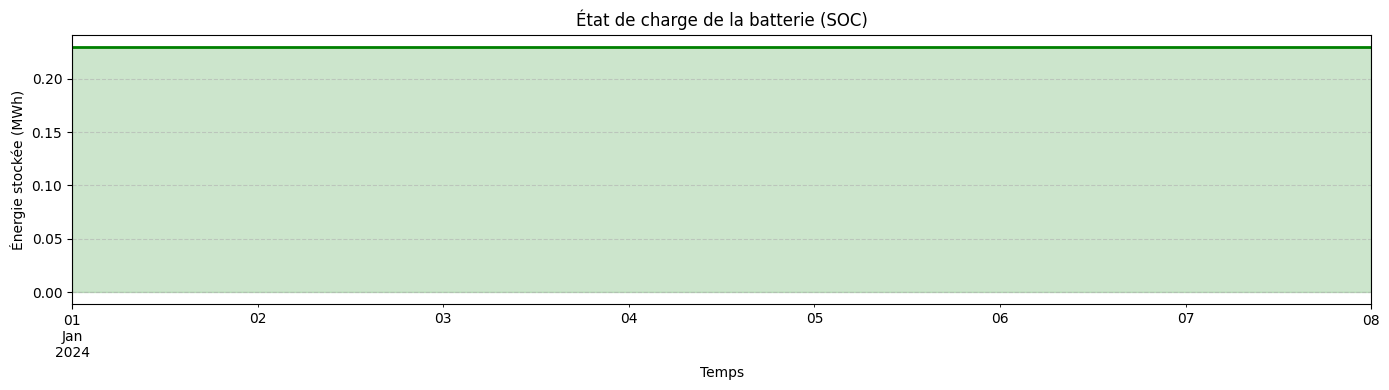

In [7]:
if "battery" in n.storage_units.index:
    fig, ax = plt.subplots(figsize=(14, 4))
    
    # Extraction de l'état de charge (SOC)
    soc = n.storage_units_t.state_of_charge.loc[time_window, "battery"]
    
    soc.plot(ax=ax, color='green', linewidth=2)
    ax.fill_between(soc.index, 0, soc, color='green', alpha=0.2)
    
    ax.set_title("État de charge de la batterie (SOC)")
    ax.set_ylabel("Énergie stockée (MWh)")
    ax.set_xlabel("Temps")
    ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("Pas de batterie dans ce scénario.")

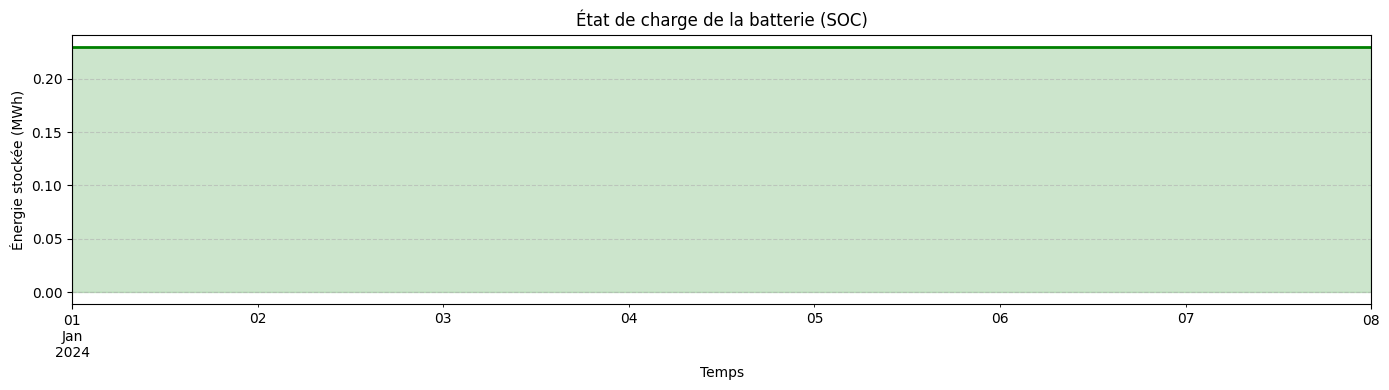

In [8]:
if "battery" in n.storage_units.index:
    fig, ax = plt.subplots(figsize=(14, 4))
    
    # Extraction de l'état de charge (SOC)
    soc = n.storage_units_t.state_of_charge.loc[time_window, "battery"]
    
    soc.plot(ax=ax, color='green', linewidth=2)
    ax.fill_between(soc.index, 0, soc, color='green', alpha=0.2)
    
    ax.set_title("État de charge de la batterie (SOC)")
    ax.set_ylabel("Énergie stockée (MWh)")
    ax.set_xlabel("Temps")
    ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("Pas de batterie dans ce scénario.")

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def generate_pareto_front(df, pv_range, bat_range):
    """
    Simule plusieurs dimensionnements de PV et Batterie pour générer un front de Pareto.
    
    :param df: DataFrame des données
    :param pv_range: Liste ou array des capacités PV à tester (en MW)
    :param bat_range: Liste ou array des capacités Batterie à tester (en MWh)
    """
    results = []
    
    # 1. On crée le réseau de base UNE SEULE FOIS pour gagner du temps
    # On met des valeurs initiales arbitraires (elles seront écrasées)
    network = pfo.create_pypsa_network(df, PV_nominal_capacity=0, Battery=True)
    
    # 2. Boucle sur toutes les combinaisons possibles (Grid Search)
    for pv_size in pv_range:
        for bat_size in bat_range:
            
            # Mise à jour des capacités installées (CAPEX)
            network.generators.loc["solar", "p_nom"] = pv_size
            network.storage_units.loc["battery", "p_nom"] = bat_size
            
            # Calcul du CAPEX annualisé pour cette itération
            capex_pv = pv_size * cfg.SOLAR_ANNUALISED_COST
            capex_bat = bat_size * cfg.BATTERY_ANNUALISED_COST
            total_capex = capex_pv + capex_bat
            
            # 3. Lancement de l'optimisation (calcul de l'OPEX par PyPSA)
            # On masque les logs de PyPSA pour ne pas polluer la console
            status, condition = network.optimize(logging_level='ERROR')
            
            if status == 'ok':
                # L'objectif de PyPSA ici (puisque le CAPEX est fixe) correspond à l'OPEX
                total_opex = network.objective 
                
                # Sauvegarde des résultats
                results.append({
                    'PV_MW': pv_size,
                    'Bat_MWH': bat_size,
                    'CAPEX': total_capex,
                    'OPEX': total_opex,
                    'Total_Cost': total_capex + total_opex
                })
                
    # 4. Conversion en DataFrame pour faciliter le traçage
    df_results = pd.DataFrame(results)
    
    return df_results

# --- UTILISATION ---
# Définir les plages à tester autour de l'optimum trouvé par PyPSA (22 MW PV / 10 MW Bat)
pv_test_range = np.arange(0, 35, 5) # Teste de 0 à 30 MW par pas de 5
bat_test_range = np.arange(0, 20, 2) # Teste de 0 à 18 MW par pas de 2

print("Calcul des scénarios en cours... Cela peut prendre un moment.")
df_pareto = generate_pareto_front(df, pv_test_range, bat_test_range)

/var/folders/_p/lntvskx96x323cvnklm36kvh0000gn/T/ipykernel_1103/1956852879.py:34: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = network.optimize(logging_level='ERROR')
Index(['bus_main', 'bus_ship', 'bus_solar', 'bus_battery'], dtype='str', name='name')
Index(['link_shore_power', 'link_solar_main', 'link_battery_to_main',
       'link_main_to_battery', 'link_solar_to_battery'],
      dtype='str', name='name')


Calcul des scénarios en cours... Cela peut prendre un moment.


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - logging_level: ERROR
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 753.69it/s]
INFO:linopy.io: Writing time: 0.05s
Status: warning
Termination condition: infeasible
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: Infeasible

/var/folders/_p/lntvskx96x323cvnklm36kvh0000gn/T/ipykernel_1103/1956852879.py:34: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = network.optimize(logging_level='ERROR')
Index(['bus_main', 'bus_ship', 'bus_solar', 'bus_battery'], dtype='str', name='name')
Index(['link_shore_power', 'link_solar_main', 'link_battery_to_main',
       'link

ERROR:   getOptionIndex: Option "logging_level" is unknown
Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-qduv0uk4 has 219600 rows; 87840 cols; 333791 nonzeros
Coefficient ranges:
  Matrix  [9e-01, 1e+00]
  Cost    [1e-02, 2e+02]
  Bound   [0e+00, 0e+00]
  RHS     [1e-02, 1e+06]
Presolving model
Problem status detected on presolve: Infeasible
Model name          : linopy-problem-qduv0uk4
Model status        : Infeasible
Objective value     :  0.0000000000e+00
HiGHS run time      :          0.04


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - logging_level: ERROR
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 624.13it/s]
INFO:linopy.io: Writing time: 0.05s


...

      31550     2.0632440937e+06 Pr: 0(0); Du: 0(3.29514e-13) 0.4s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-ts8934bw
Model status        : Optimal
Simplex   iterations: 31550
Objective value     :  2.0632440937e+06
P-D objective error :  1.4105855673e-15
HiGHS run time      :          0.41


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - logging_level: ERROR
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 649.76it/s]
INFO:linopy.io: Writing time: 0.06s


ERROR:   getOptionIndex: Option "logging_level" is unknown
Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-cwnw4_fd has 219600 rows; 87840 cols; 333791 nonzeros
Coefficient ranges:
  Matrix  [9e-01, 1e+00]
  Cost    [1e-02, 2e+02]
  Bound   [0e+00, 0e+00]
  RHS     [5e-04, 1e+06]
Presolving model
31123 rows, 67017 cols, 120478 nonzeros  0s
27110 rows, 54220 cols, 94884 nonzeros  0s
Dependent equations search running on 22333 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
22333 rows, 49443 cols, 85324 nonzeros  0s
Presolve reductions: rows 22333(-197267); columns 49443(-38397); nonzeros 85324(-248467) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87840 primals, 219600 duals
Objective: 2.04e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      31495     2.0446914802e+06 Pr: 0(0); Du: 0(3.42837e-13) 0.4s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-cwnw4_fd
Model status        : Optimal
Simplex   iterations: 31495
Objective value     :  2.0446914802e+06
P-D objective error :  6.8322460080e-16
HiGHS run time      :          0.41


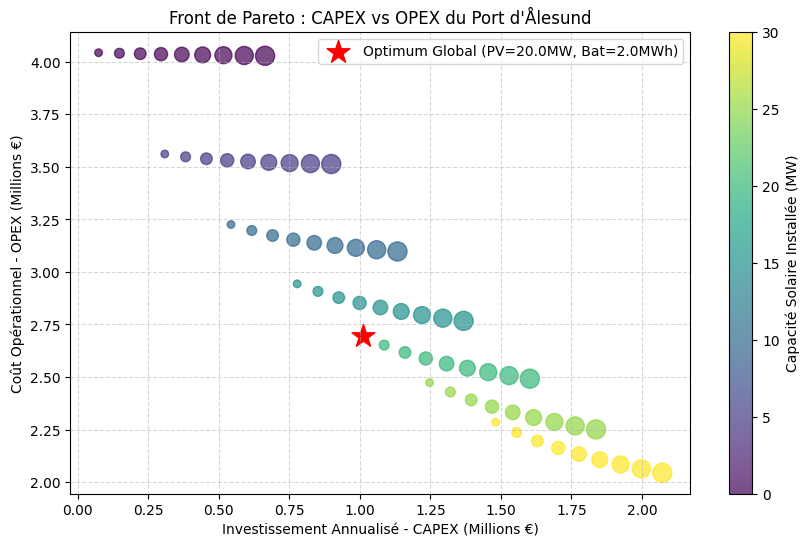

In [12]:
def plot_pareto(df_results):
    plt.figure(figsize=(10, 6))
    
    # Tracer tous les points testés
    scatter = plt.scatter(df_results['CAPEX'] / 1e6, 
                          df_results['OPEX'] / 1e6, 
                          c=df_results['PV_MW'], 
                          cmap='viridis', 
                          s=df_results['Bat_MWH']*10 + 10, # La taille du point = taille de la batterie
                          alpha=0.7)
    
    plt.colorbar(scatter, label='Capacité Solaire Installée (MW)')
    
    # Mettre en évidence le point optimal trouvé par l'algorithme (Total minimum)
    optimum = df_results.loc[df_results['Total_Cost'].idxmin()]
    plt.scatter(optimum['CAPEX'] / 1e6, optimum['OPEX'] / 1e6, 
                color='red', marker='*', s=300, label=f"Optimum Global (PV={optimum['PV_MW']}MW, Bat={optimum['Bat_MWH']}MWh)")
    
    plt.title("Front de Pareto : CAPEX vs OPEX du Port d'Ålesund")
    plt.xlabel("Investissement Annualisé - CAPEX (Millions €)")
    plt.ylabel("Coût Opérationnel - OPEX (Millions €)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

plot_pareto(df_pareto)